# Combining Sample and Control Files (qc, blank, env blank) for later removing contamination

In [1]:
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.spatial.distance import pdist
from difflib import get_close_matches
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from itertools import combinations
 

# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_18.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_35.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_90.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_54.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]
# Replace these with  actual QC, env, blank file paths beacuse we want to remove the contamination and get the actual peaks for samples
qc_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")
all_files = (
    [(f,"sample") for f in sample_files] +
    [(f, "qc") for f in qc_files] +
    [(f, "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)
rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
compound_df = pd.concat(rows, ignore_index=True)
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV to use it later
compound_df .to_csv(output_path, index=False)
print(f"compound dataset saved to: {output_path}")
compound_df.head()

compound dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Filtering True Sample Compounds

In [2]:
# Exclude compounds found in blanks/QCs/env
exclude = compound_df.loc[
    compound_df['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Keep only actual sample compounds, removing excluded ones
real = compound_df.loc[
    (compound_df['FileType'] == 'sample') &
    (~compound_df['Compound Name'].isin(exclude))
].copy()

# Print filtered data shape and show head
print("Filtered sample compounds:", real.shape)
real.head()

Filtered sample compounds: (2498, 7)


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


In [3]:
import pandas as pd
import numpy as np
import re


cleaned_sample_data=pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\cleaned_features_with_meta.csv")

# Step 1: Build sample_matching dictionary automatically
sample_matching = {}
for col in cleaned_sample_data.columns:
    match = re.search(r'S96_(\d+)_B1_D\d+_T1', col)
    if match:
        sample_num = match.group(1)
        filename = f'sample_{sample_num}.csv'
        sample_matching[filename] = col

# Manually add missing samples 46 and 47
sample_matching['sample_46.csv'] = 's179 S96_46_B1_D10_T2'
sample_matching['sample_47.csv'] = 's148 S96_47_B1_D8_T2'

print("Sample matching dictionary with added missing samples:")
print(sample_matching)

# Step 2: Define function to find closest peak by RT with tolerance
def find_closest_peak(rt, peaks_rt, tol=0.1):
    diffs = np.abs(peaks_rt - rt)
    min_diff = diffs.min()
    if min_diff <= tol:
        return diffs.idxmin()  # index of closest peak
    else:
        return None

# Step 3: Match compounds to intensities in cleaned_sample_data
matches = []
peaks_rt = cleaned_sample_data['tR_best']

for i, row in compound_df.iterrows():
    file_name = row['FileName']
    sample_col = sample_matching.get(file_name)
    if sample_col is None:
        # No matching sample column found for this compound
        continue
    
    compound_rt = row['Component RT']
    peak_idx = find_closest_peak(compound_rt, peaks_rt)
    
    if peak_idx is None:
        # No peak found within tolerance for this compound RT
        continue
    
    intensity = cleaned_sample_data.loc[peak_idx, sample_col]
    
    matches.append({
        'Compound Name': row['Compound Name'],
        'FileName': file_name,
        'Sample': sample_col,
        'Component RT': compound_rt,
        'Peak': cleaned_sample_data.loc[peak_idx, 'Peak'],
        'tR_best': cleaned_sample_data.loc[peak_idx, 'tR_best'],
        'm/z': cleaned_sample_data.loc[peak_idx, 'm/z'],
        'Intensity': intensity
    })

# Step 4: Create final matched DataFrame
compound_intesity_df = pd.DataFrame(matches)

print(f"Number of matched compound intensities: {compound_intesity_df .shape[0]}")
print(compound_intesity_df .head())
print(compound_intesity_df.shape)

Sample matching dictionary with added missing samples:
{'sample_10.csv': 's26 S96_10_B1_D2_T1', 'sample_11.csv': 's169 S96_11_B1_D10_T1', 'sample_12.csv': 's78 S96_12_B1_D5_T1', 'sample_13.csv': 's153 S96_13_B1_D9_T1', 'sample_14.csv': 's2 S96_14_B1_D1_T1', 'sample_15.csv': 's93 S96_15_B1_D6_T1', 'sample_16.csv': 's39 S96_16_B1_D3_T1', 'sample_17.csv': 's151 S96_17_B1_D9_T1', 'sample_18.csv': 's59 S96_18_B1_D4_T1', 'sample_19.csv': 's174 S96_19_B1_D10_T1', 'sample_1.csv': 's80 S96_1_B1_D5_T1', 'sample_20.csv': 's152 S96_20_B1_D9_T1', 'sample_21.csv': 's6 S96_21_B1_D1_T1', 'sample_22.csv': 's137 S96_22_B1_D8_T1', 'sample_23.csv': 's154 S96_23_B1_D9_T1', 'sample_24.csv': 's119 S96_24_B1_D7_T1', 'sample_25.csv': 's95 S96_25_B1_D6_T1', 'sample_26.csv': 's140 S96_26_B1_D8_T1', 'sample_27.csv': 's157 S96_27_B1_D9_T1', 'sample_28.csv': 's4 S96_28_B1_D1_T1', 'sample_29.csv': 's150 S96_29_B1_D9_T1', 'sample_2.csv': 's114 S96_2_B1_D7_T1', 'sample_30.csv': 's79 S96_30_B1_D5_T1', 'sample_31.csv': 

In [4]:
compound_intesity_df .to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_intensity.csv", index=False)
len(compound_intesity_df['Sample'].unique())

94

# Checking the presence of known potato aroma compounds

In [5]:
from difflib import get_close_matches

# Your list of potato aroma compounds
potato_aromas = [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-",
    "Heptanal", "Octanal", "Decanal",
    "2-Heptanone", "2-Nonanone", "3-Heptanone",
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",
    "2-Ethyl-3,5-dimethylpyrazine", "2-Isobutyl-3-methoxypyrazine",
    "1-Heptanol", "1-Nonanol",
    "Methanethiol", "Dimethyl tetrasulfide", "Carbon disulfide",
    "Acetic acid", "Butanoic acid", "Hexanoic acid"
]

def normalize(name):
    return name.lower().replace(' ', '').replace('-', '').replace(',', '')

# Normalize aroma list into dictionary: normalized name -> original name
ref_norm = {normalize(x): x for x in potato_aromas}

# Normalize compound names in matched_df
compound_intesity_df['norm_name'] = compound_intesity_df['Compound Name'].apply(normalize)

# Exact matches
compound_intesity_df['is_aroma'] =compound_intesity_df['norm_name'].isin(ref_norm)

# Fuzzy matching for compounds not exactly matched
def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

mask = ~compound_intesity_df['is_aroma']
fuzzy_hits = compound_intesity_df.loc[mask, 'norm_name'].map(lambda n: fuzzy_match(n, list(ref_norm.keys())))

# Mark fuzzy matched as aroma and update 'Compound Name' with official name
compound_intesity_df.loc[mask & fuzzy_hits.notna(), 'is_aroma'] = True
compound_intesity_df.loc[mask & fuzzy_hits.notna(), 'Compound Name'] = fuzzy_hits.map(ref_norm)

# Filter only aroma compounds
aroma_sample_df = compound_intesity_df[compound_intesity_df['is_aroma']].copy()

print(f"Number of aroma compound records: {aroma_sample_df.shape[0]}")
print(aroma_sample_df.head())


Number of aroma compound records: 543
                   Compound Name      FileName              Sample  \
0             Butanal, 3-methyl-  sample_7.csv  s18 S96_7_B1_D1_T1   
1                       Pentanal  sample_7.csv  s18 S96_7_B1_D1_T1   
3                        Hexanal  sample_7.csv  s18 S96_7_B1_D1_T1   
4  Cyclotrisiloxane, hexamethyl-  sample_7.csv  s18 S96_7_B1_D1_T1   
5                   Benzaldehyde  sample_7.csv  s18 S96_7_B1_D1_T1   

   Component RT  Peak  tR_best  m/z  Intensity                   norm_name  \
0      2.899483    27    2.890   44  15.879306              butanal3methyl   
1      3.317483    41    3.375   81  19.455887                    pentanal   
3      5.282067    73    5.199  149  15.227984                     hexanal   
4      5.883333    80    5.903  207  17.026906  cyclotrisiloxanehexamethyl   
5      9.314117   145    9.347  267  17.161132                benzaldehyde   

   is_aroma  
0      True  
1      True  
3      True  
4      True  
5 

# Map variety on samples

In [8]:
import pandas as pd

# Load master table
master = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
)

# Extract SampleNumber from your aroma_samples 'FileName' (assumes sample_##.csv format)
aroma_sample_df['SampleNumber'] = aroma_sample_df['FileName'].str.extract(r'(\d+)').astype(int)

# Filter master table to exclude blanks/QC etc.
valid_master = master[
    ~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])
].copy()

# Extract SampleNumber from master 'Filename' column, e.g. "_12_B" => 12
valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B').astype(int)

# Extract Variety from master 'Sample' column
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()

# Prepare mapping table: SampleNumber -> Variety (remove duplicates)
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge variety info into aroma_samples by SampleNumber
aroma_per_variety = pd.merge(aroma_sample_df, sample_to_variety, on='SampleNumber', how='left')

# Drop the FileName column (if you don't need it)
aroma_per_variety = aroma_per_variety.drop(columns=['FileName'])

# Now print without the FileName column
print(aroma_per_variety.head(20))



                    Compound Name              Sample  Component RT  Peak  \
0              Butanal, 3-methyl-  s18 S96_7_B1_D1_T1      2.899483    27   
1                        Pentanal  s18 S96_7_B1_D1_T1      3.317483    41   
2                         Hexanal  s18 S96_7_B1_D1_T1      5.282067    73   
3   Cyclotrisiloxane, hexamethyl-  s18 S96_7_B1_D1_T1      5.883333    80   
4                    Benzaldehyde  s18 S96_7_B1_D1_T1      9.314117   145   
5             Dimethyl trisulfide  s18 S96_7_B1_D1_T1      9.519900   149   
6                         Octanal  s18 S96_7_B1_D1_T1     10.191900   172   
7                         Decanal  s18 S96_7_B1_D1_T1     13.703067   274   
8              Butanal, 3-methyl-  s2 S96_14_B1_D1_T1      2.902783    27   
9                         Hexanal  s2 S96_14_B1_D1_T1      5.282150    73   
10  Cyclotrisiloxane, hexamethyl-  s2 S96_14_B1_D1_T1      5.883417    80   
11                   Benzaldehyde  s2 S96_14_B1_D1_T1      9.319350   145   

# Top aroma per varaiety

In [9]:
# Total intensity of each aroma compound per variety
aroma_sum = aroma_per_variety.groupby(['Variety', 'Compound Name'])['Intensity'].sum().reset_index()

# Top aromas per variety (sorted by total intensity)
top_aromas_per_variety = aroma_sum.sort_values(['Variety', 'Intensity'], ascending=[True, False])

print(top_aromas_per_variety.head(20))


     Variety                  Compound Name  Intensity
3      ADORA                        Decanal  36.406676
4      ADORA                  Hexanoic acid  22.334351
5      ADORA                        Octanal  18.799602
0      ADORA                   Benzaldehyde  17.984870
2      ADORA  Cyclotrisiloxane, hexamethyl-  17.417208
1      ADORA             Butanal, 3-methyl-  15.836435
12     AGRIA                       Pentanal  18.039118
10     AGRIA            Dimethyl trisulfide  17.210770
8      AGRIA  Cyclotrisiloxane, hexamethyl-  15.947810
11     AGRIA                        Octanal  15.924101
6      AGRIA                   Benzaldehyde  14.859493
9      AGRIA                        Decanal  14.499810
7      AGRIA             Butanal, 3-methyl-  14.154847
16  ALOUETTE                        Decanal  34.924743
17  ALOUETTE                        Octanal  19.520823
14  ALOUETTE             Butanal, 3-methyl-  15.262178
13  ALOUETTE                   Benzaldehyde  15.205705
15  ALOUET

Heatmap of Aroma Intensities Across Varieties

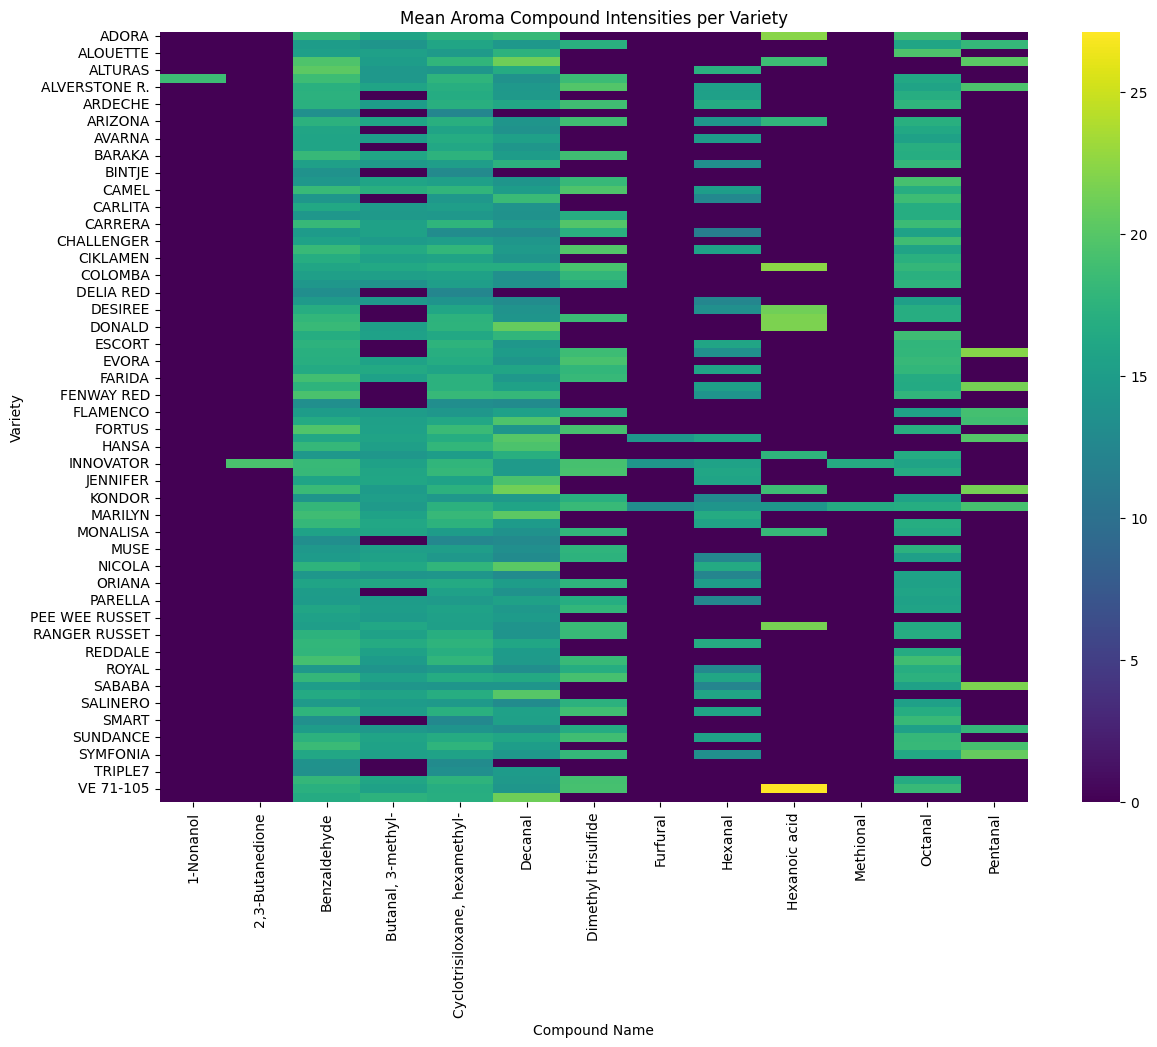

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot data to wide format: rows=varieties, columns=compounds, values=mean intensity
pivot_df = aroma_per_variety.pivot_table(index='Variety', columns='Compound Name', values='Intensity', aggfunc='mean', fill_value=0)

plt.figure(figsize=(14,10))
sns.heatmap(pivot_df, cmap='viridis')
plt.title("Mean Aroma Compound Intensities per Variety")
plt.xlabel("Compound Name")
plt.ylabel("Variety")
plt.show()


PCA on Aroma Profiles

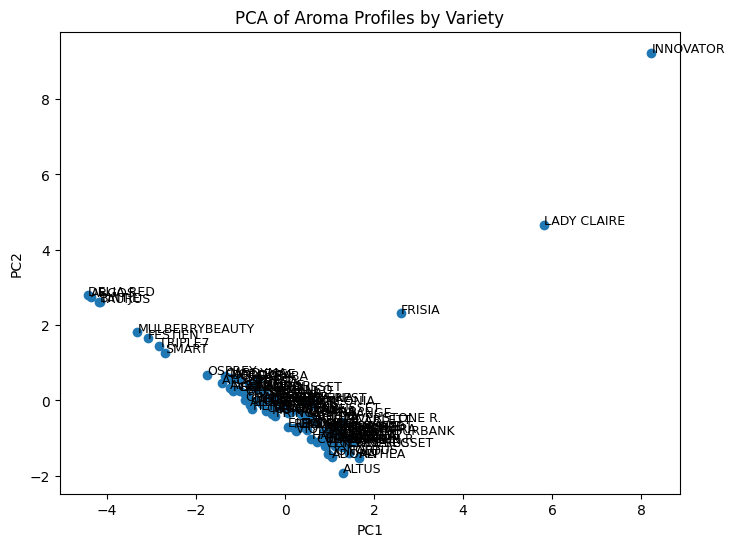

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale aroma intensities (mean=0, std=1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Plot PCA result
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1])

# Annotate with variety names
for i, variety in enumerate(pivot_df.index):
    plt.text(pca_result[i,0], pca_result[i,1], variety, fontsize=9)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Aroma Profiles by Variety")
plt.show()
